<a href="https://colab.research.google.com/github/sys8815701-creator/AI_26/blob/main/05_03_%ED%8A%B8%EB%A6%AC%EC%95%99%EC%83%81%EB%B8%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 테스트 세트를 제외하고 검증 세트를 사용하는 cv(교차 검증), 하이퍼 파라미터 튜닝 등을 사용해보자.
# Colab에는 웬만한 AI용 라이브러리가 설치되어 있지만, 그럼에도 설치 안 되어 있는 것은 수동으로 설치해야 한다.
!pip install xgboost
!pip install pycaret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 3.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pmdarima to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 5.3 M

In [ ]:
# 앙상블 : 여러 단순한 모델을 결합하여 정확한 모델을 만드는 방법
# 정형 데이터 : 지금까지 학습한 수치 자료가 있는 값
# 비정형 데이터 : 데이터베이스 혹은 엑셀로 표현하기 어려운 데이터

# 랜덤 포레스트 : 결정 트리를 무작위로 생성하여 결정 트리 숲을 만든다. → 최종적으로 예측한다.

# 1,000개의 샘플이 들어 있는 가방에서 100개의 샘플을 뽑을 때, 1개를 뽑고 뽑았던 1개를 다시 가방에 넣는다. → 이때 중복된 샘플을 뽑는 것을 부트스트랩 샘플이라고 한다.
# 부트스트랩 샘플 : 데이터 세트에서 중복을 허용하여 데이터를 샘플링 한다.

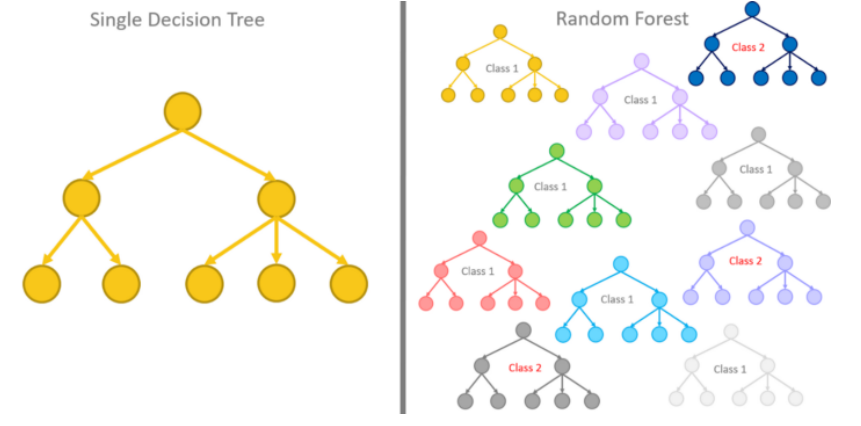

In [ ]:
# RandomForestClassifier : 분류 모델로서, 기본적으로 전체 특성 개수의 제곱근만큼 특성을 선택한다. (e.g. 4개의 특성이 있다면 노드마다 2개를 무작위로 선택하여 사용한다.) <-> RandomForestRegressor : 회귀 모델로서, 전체 특성을 사용한다.
# 사이킷런의 랜덤 포레스트 : 기본적으로 100개의 결정 트리를 이러한 방식으로 훈련한다.

# 분류의 경우, 각 트리의 클래스별 확률을 평균낸 후, 가장 높은 확률을 가진 클래스를 예측으로 삼는다.
# 회귀의 경우, 단순하게 각 트리의 예측을 평균낸다.

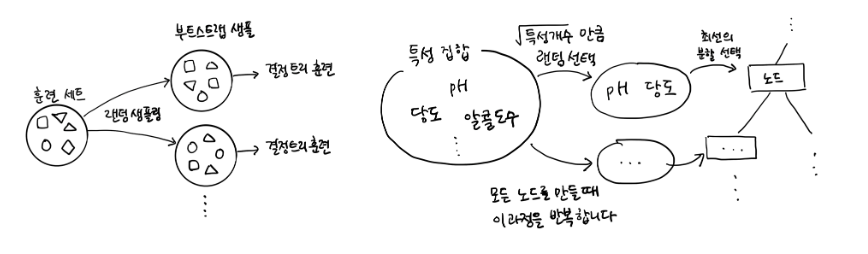

In [5]:
# 와인을 찾기 위한 데이터
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

wine = pd.read_csv('https://bit.ly/wine_csv_data')

data = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()
data

array([[ 9.4 ,  1.9 ,  3.51],
       [ 9.8 ,  2.6 ,  3.2 ],
       [ 9.8 ,  2.3 ,  3.26],
       ...,
       [ 9.4 ,  1.2 ,  2.99],
       [12.8 ,  1.1 ,  3.34],
       [11.8 ,  0.8 ,  3.26]])

In [6]:
target

array([0., 0., 0., ..., 1., 1., 1.])

In [7]:
# 훈련 세트를 80%, 테스트 세트를 20%로 나눈다.
train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42
)
print(train_input.shape, test_input.shape) # 이때 생성한 테스트 세트 20%는 검증이 끝난 마지막 단계에서 평가용으로 사용한다.

(5197, 3) (1300, 3)


In [8]:
from sklearn.model_selection import cross_validate # 크로스 검증용
from sklearn.ensemble import RandomForestClassifier # 100개의 결정 트리를 활용한다.

rf = RandomForestClassifier(n_jobs=-1, random_state=42) # n_jobs=-1 : 모든 CPU를 사용한다.
scores = cross_validate(rf, train_input, train_target, return_train_score = True, n_jobs=-1) # return_train_score = True : 검증 점수와 훈련 세트에 대한 점수를 리턴한다.

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

# 결과 : 약 99.73% (과대 적합)

0.9973541965122431 0.8905151032797809


In [10]:
# 랜덤 포레스트 : 결정 트리의 앙상블로서, 결정 트리가 제공하는 중요한 매개변수를 모두 제공한다. → 특성 중요도를 계산한다. (결정 트리의 특성 중요도를 취합한다.)
rf.fit(train_input, train_target) # 훈련한 후 특성 중요도를 출력한다.
print(rf.feature_importances_)

[0.23167441 0.50039841 0.26792718]


In [ ]:
# 알코올 도수, 당도, pH를 비교해보자.
# 랜덤 포레스트가 특성 일부를 무작위로 선택한 후 결정 트리를 훈련한다. (중복 허용) → 당도의 중요도가 감소하고, 알코올 도수와 pH 중요도가 상승한다.
# 하나의 특성에 과도하게 집중하지 않기 때문에, 좀 더 많은 특성이 훈련에 기여할 수 있다. (과대 적합 ↓)

In [12]:
rf = RandomForestClassifier(oob_score=True, n_jobs=-1, random_state=42)
# OOB(Out Of Bag) : 부트스트랩에 포함되지 않고 남은 샘플 → 결정 트리 평가용 (검증 세트로 활용한다.)
# oob_score=True : 각 결정 트리의 OOB 점수를 평균낸 후 출력한다.

rf.fit(train_input, train_target)
print(rf.oob_score_)

# 결과 ; 교차 검증의 점수와 유사한 결과가 도출된다.
# # OOB 점수를 활용하면 교차 검증을 대신할 수 있기 때문에, 결과적으로 훈련 세트에 더 많은 샘플을 사용할 수 있게 된다.

0.8934000384837406


In [13]:
# 엑스트라 트리 : 100개의 결정 트리를 훈련한다. → 부트스트랩 샘플 말고 전체 훈련 세트를 사용한다. (가장 좋은 분할을 찾는 대신 무작위로 분할한다.)
# 하나의 결정 트리에서 특성을 무작위로 분할한다면 성능이 낮아지겠지만, 많은 트리를 앙상블 하기 때문에 과대 적합을 예방하고 검증 세트의 점수를 높일 수 있다.
from sklearn.ensemble import ExtraTreesClassifier # ExtraTreesClassifier : 엑스트라 트리

et = ExtraTreesClassifier(n_jobs=-1, random_state=42)
scores =  cross_validate(et, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

# 결과 : 'RandomForestClassifier'와 유사한 결과가 도출된다. (단, 속도가 향상된다.)

0.9974503966084433 0.8887848893166506


In [14]:
et.fit(train_input, train_target)
print(et.feature_importances_)

# 결과 : 결정 트리보다 당도에 대한 의존성이 적다.

[0.20183568 0.52242907 0.27573525]


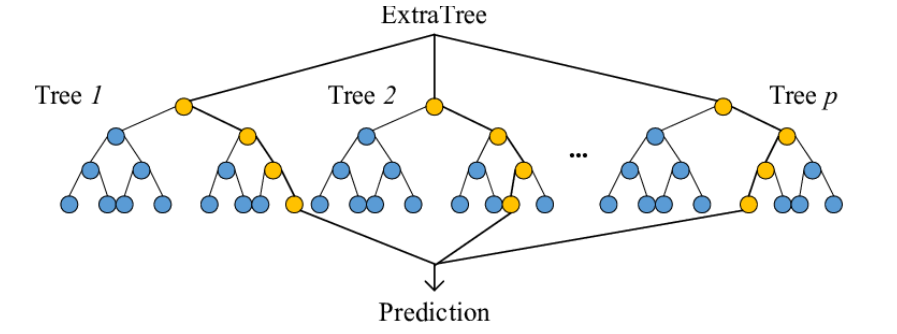

In [16]:
# Gradient Boosting : 기울기 → 깊이가 얕은 결정 트리를 활용하여 이전 트리의 오차를 보완하는 방식으로 앙상블 한다.
# 장점 : 깊이가 3인 결정 트리를 100개 사용하기 때문에 과대 적합에 강하고, 높은 일반화 성능을 기대한다.

# Gradient : 경사 하강법을 활용하여 앙상블에 트리를 추가한다.
# 분류의 경우 로지스틱 손실 함수를 사용하고, 회귀의 경우 평균 제곱 오차 함수를 사용한다.

from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

# 결과 : 과대 적합이 해결되었다.

0.8881086892152563 0.8720430147331015


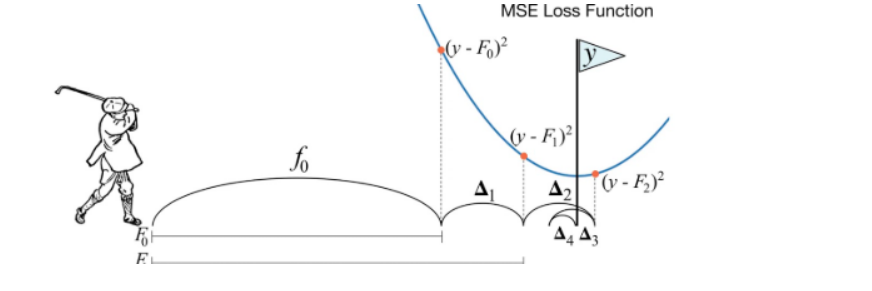

In [18]:
gb = GradientBoostingClassifier(n_estimators=500, learning_rate=0.2, random_state=42)
# n_estimators=500 : 결정 트리 개수를 500개로 늘린다. (기본값 : 100)
# learning_rate=n : 학습률 (기본값 : 0.1)

scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 교차 검증 점수를 확인한다.

# 결과 : 과대 적합이 아니다.

0.9464595437171814 0.8780082549788999


In [22]:
gb.fit(train_input, train_target) # 훈련을 시작한다.
print(gb.feature_importances_)

# 결과 : 당도에 대한 의존도가 낮고, 순서대로 트리를 추가하기 때문에 훈련 속도가 조금 느리다.

[0.15887763 0.6799705  0.16115187]


In [27]:
# Histogram Gradient : 히스토그램 기반 그레이디언트 부스팅 → 입력 특성을 256 구간으로 나누기 때문에, 노드 분할 시 최적의 분할을 매우 빠르게 찾을 수 있다.
# 장점 : 입력 특성을 256 구간으로 나누기 때문에, 노드 분할 시 최적의 분할을 매우 빠르게 찾을 수 있다.
from sklearn.ensemble import HistGradientBoostingClassifier # 분류용

hgb = HistGradientBoostingClassifier(random_state=42)
scores = cross_validate(hgb, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['test_score']), np.mean(scores['test_score']))

0.8801241948619236 0.8801241948619236


In [30]:
from sklearn.inspection import permutation_importance # permutation_importance : 특성의 중요도를 확인한다. → 특성을 하나씩 무작위로 섞은 후, 모델의 성능이 변화되는지 관찰한다.

# 히스토그램 기반의 훈련을 진행한다. → 훈련 세트에서 특성의 중요도를 계산해보자.
hgb.fit(train_input, train_target)

# n_repeats=n : 무작위로 섞을 횟수 (기본값 : 5)
result = permutation_importance(hgb, train_input, train_target, n_repeats=10,
                                random_state=42, n_jobs=-1)
print(result.importances_mean)

[0.08876275 0.23438522 0.08027708]


In [31]:
# 테스트 세트의 결과를 확인해보자.
result = permutation_importance(hgb, test_input, test_target, n_repeats=10,
                                random_state=42, n_jobs=-1)
print(result.importances_mean)

[0.05969231 0.20238462 0.049     ]


In [32]:
# 사이킷런 말고 그레이디언트 부스팅 알고리즘을 구현한 라이브러리가 다수 존재한다.
from xgboost import XGBClassifier

xgb = XGBClassifier(tree_method='hist', random_state=42)
scores =  cross_validate(xgb, train_input, train_target, return_train_score=True, n_jobs=-1)
# tree_method='hist' : 히스토그램 기반 그레이디언트 부스팅 용도
# 만약 실행이 안 된다면 파이썬에 설치해야 한다.
# !pip install xgboost
# !pip install pycaret → 세션을 다시 시작한 후 위에서부터 다시 객체를 생성한다.

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9567059184812372 0.8783915747390243


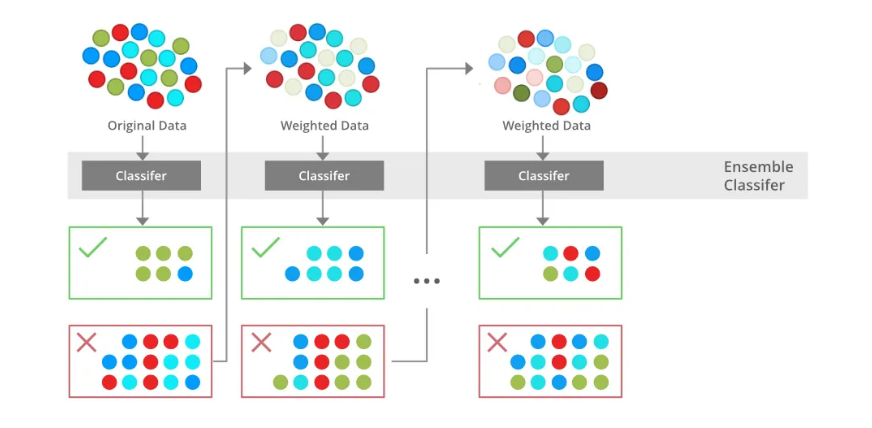

In [33]:
# 'LGBMClassifier ms'에서 만든 'LightGBM^2'
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(random_state=42)
scores = cross_validate(lgb, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.935828414851749 0.8801251203079884
